<a href="https://colab.research.google.com/github/mugalan/introduction-to-statistical-learning/blob/main/assignments/Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

**Assumptions:**
Let the process noise $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ and measurement noise $z_k \sim \mathscr{N}(0, \Sigma_m)$ be independent, zero-mean Gaussian variables, mutually independent from the prior state $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$.

---

### **1. Show that $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$**

Given the state prediction model:
$$x^{-}_k = A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}$$

Since $x^{-}_k$ is a linear combination of two independent Gaussian variables, it is also Gaussian.

**Mean ($m_k^-$):**
Applying the linearity of expectation:
$$m_k^- = \mathbb{E}[x^{-}_k] = \mathbb{E}[A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}]$$
$$m_k^- = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$$
Since $\mathbb{E}[x^{+}_{k-1}] = m_{k-1}$ and $\mathbb{E}[w_{k-1}] = 0$:
$$m_k^- = A_{k-1}m_{k-1}$$

**Covariance ($P_k^-$):**
Since $x^{+}_{k-1}$ and $w_{k-1}$ are independent, the cross-variance terms are zero:
$$P_k^- = \text{Var}(A_{k-1}\,x^{+}_{k-1}) + \text{Var}(G_{k-1}\,w_{k-1})$$
$$P_k^- = A_{k-1}\text{Var}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$
$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

Therefore, $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$.

---

### **2. Show that $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$**

Given the measurement prediction model:
$$y^{-}_k = H_k\,x^{-}_k + z_k$$

**Mean:**
$$\mathbb{E}[y^{-}_k] = \mathbb{E}[H_k\,x^{-}_k + z_k]$$
$$\mathbb{E}[y^{-}_k] = H_k\mathbb{E}[x^{-}_k] + \mathbb{E}[z_k]$$
$$\mathbb{E}[y^{-}_k] = H_k m_k^- + 0 = H_k m_k^-$$

**Covariance:**
Since $x^{-}_k$ and $z_k$ are independent:
$$\text{Var}(y^{-}_k) = \text{Var}(H_k\,x^{-}_k) + \text{Var}(z_k)$$
$$\text{Var}(y^{-}_k) = H_k \text{Var}(x^{-}_k) H_k^T + \Sigma_m$$
$$\text{Var}(y^{-}_k) = H_k P_k^- H_k^T + \Sigma_m$$

Therefore, $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$.

---

### **3. Show the Joint Distribution of $x_k^-$ and $y_k^-$**

Since $y^{-}_k$ is an affine transformation of $x^{-}_k$ with added independent Gaussian noise, they are jointly Gaussian. We must find the cross-covariance $\text{Cov}(x_k^-, y_k^-)$.

$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - \mathbb{E}[x_k^-])(y_k^- - \mathbb{E}[y_k^-])^T]$$
Substitute $y_k^- = H_k x_k^- + z_k$ and $\mathbb{E}[y_k^-] = H_k m_k^-$:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-) \left(H_k(x_k^- - m_k^-) + z_k\right)^T\right]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)(x_k^- - m_k^-)^T H_k^T + (x_k^- - m_k^-)z_k^T\right]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[(x_k^- - m_k^-)z_k^T]$$

Because $x_k^-$ and $z_k$ are independent, $\mathbb{E}[(x_k^- - m_k^-)z_k^T] = 0$. The first expectation is the covariance $P_k^-$:
$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T$$

By symmetry, $\text{Cov}(y_k^-, x_k^-) = H_k P_k^-$. Combining the means and covariance blocks yields:
$$
\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)
$$

---

### **4. Show that $x^{+}_k \sim \mathscr{N}(m_k, P_k)$**

The updated state $x^{+}_k$ is the conditional distribution $(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$. By the properties of jointly Gaussian vectors, conditioning one variable on another results in a new Gaussian distribution.

Given a joint distribution:
$$
\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix} \right)
$$
The conditional mean and covariance are:
1. Mean: $\mu_{X|Y} = \mu_X + \Sigma_{XY} \Sigma_{YY}^{-1} (y - \mu_Y)$
2. Covariance: $\Sigma_{X|Y} = \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX}$

Using the joint distribution matrix from Part 3, define the Kalman Gain $K_k$ as $\Sigma_{XY} \Sigma_{YY}^{-1}$:
$$K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

Applying the conditional formulas gives the updated state parameters:
$$m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$
$$P_k = P_k^- - K_k (H_k P_k^-) = (I - K_k H_k) P_k^-$$

Therefore, $x^{+}_k \sim \mathscr{N}(m_k, P_k)$.

---

### **5. Find $\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$ and $\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$**

We solve for these values by direct substitution from the joint matrix blocks in Part 3 into the conditional Gaussian theorem.

Let:
* $\mu_X = m_k^-$
* $\mu_Y = H_k m_k^-$
* $\Sigma_{XX} = P_k^-$
* $\Sigma_{YY} = H_k P_k^- H_k^T + \Sigma_m$
* $\Sigma_{XY} = P_k^- H_k^T$
* $\Sigma_{YX} = H_k P_k^-$

**Finding the Expectation:**
$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = \mu_X + \Sigma_{XY} \Sigma_{YY}^{-1} (y^{\mathrm{obs}}_{k} - \mu_Y)$$
Substitute $K_k = \Sigma_{XY} \Sigma_{YY}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$:
$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

**Finding the Variance:**
$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX}$$
Substitute the defined matrices and $K_k$:
$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k^- - K_k (H_k P_k^-)$$
Factor out $P_k^-$ from the right:
$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = (I - K_k H_k) P_k^-$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

### **1. State Prediction Distribution ($m_k^-$ and $P_k^-$)**

Given the scalar system model:
$$x^-_k = a\,x^+_{k-1} + w_{k-1}$$
where the prior state is $x^+_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and the process noise is $w_{k-1} \sim \mathscr{N}(0, q)$. We assume $x^+_{k-1}$ and $w_{k-1}$ are independent.

**Predictive Mean ($m_k^-$):**
Taking the expectation of the system model:
$$m_k^- = \mathbb{E}[x^-_k] = \mathbb{E}[a\,x^+_{k-1} + w_{k-1}]$$
$$m_k^- = a\mathbb{E}[x^+_{k-1}] + \mathbb{E}[w_{k-1}]$$
Since $\mathbb{E}[w_{k-1}] = 0$:
$$m_k^- = a\,m_{k-1}$$

**Predictive Variance ($P_k^-$):**
Taking the variance of the system model:
$$P_k^- = \text{Var}(x^-_k) = \text{Var}(a\,x^+_{k-1} + w_{k-1})$$
Because the state and the process noise are independent, the variance of their sum is the sum of their variances:
$$P_k^- = \text{Var}(a\,x^+_{k-1}) + \text{Var}(w_{k-1})$$
$$P_k^- = a^2 \text{Var}(x^+_{k-1}) + q$$
$$P_k^- = a^2 P_{k-1} + q$$

---

### **2. State Update Distribution ($m_k$ and $P_k$)**

The measurement model is:
$$y^-_k = h\,x^-_k + z_k$$
where $z_k \sim \mathscr{N}(0, r)$ is independent of $x^-_k$.

To find the posterior (updated) distribution $x^+_k = (x^-_k \mid y_k = y^{\mathrm{obs}}_k)$, we use the properties of joint Gaussian distributions.
First, identify the statistics of $y^-_k$ and its cross-covariance with $x^-_k$:
* **Measurement Mean:** $\mathbb{E}[y^-_k] = h\,m_k^-$
* **Measurement Variance (Innovation Covariance, $S_k$):** $\text{Var}(y^-_k) = h^2 P_k^- + r \triangleq S_k$
* **Cross-Covariance:** $\text{Cov}(x^-_k, y^-_k) = \text{Cov}(x^-_k, h\,x^-_k + z_k) = h\text{Var}(x^-_k) = h\,P_k^-$

The standard formula for conditioning jointly Gaussian variables gives the Kalman Gain ($K_k$) as the ratio of cross-covariance to measurement variance:
$$K_k = \frac{\text{Cov}(x^-_k, y^-_k)}{\text{Var}(y^-_k)} = \frac{P_k^- h}{S_k}$$

**Updated Mean ($m_k$):**
$$m_k = \mathbb{E}[x^-_k] + K_k(y^{\mathrm{obs}}_k - \mathbb{E}[y^-_k])$$
$$m_k = m_k^- + K_k(y^{\mathrm{obs}}_k - h\,m_k^-)$$
$$m_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$

**Updated Variance ($P_k$):**
$$P_k = \text{Var}(x^-_k) - K_k\text{Cov}(y^-_k, x^-_k)$$
$$P_k = P_k^- - K_k(h\,P_k^-)$$
$$P_k = (1 - K_k h)\,P_k^-$$
Substitute $K_k$:
$$P_k = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

---

### **3. Predictive Measurement Distribution**

Before processing the actual observation $y^{\mathrm{obs}}_k$, we want the distribution of the expected measurement given all previous data $Y_{k-1}$.
This relies entirely on the predicted state $x^-_k \sim \mathscr{N}(m_k^-, P_k^-)$.

$$y^-_k = h\,x^-_k + z_k$$
Taking expectations conditioned on $Y_{k-1}$:
$$\mathbb{E}[y^-_k \mid Y_{k-1}] = h\,\mathbb{E}[x^-_k \mid Y_{k-1}] + \mathbb{E}[z_k] = h\,m_k^-$$
Taking variances conditioned on $Y_{k-1}$:
$$\text{Var}(y^-_k \mid Y_{k-1}) = h^2\text{Var}(x^-_k \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$$

Since it is a linear combination of Gaussians, the distribution is Gaussian:
$$p(y^-_k \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

---

### **4. Posterior-Predictive Measurement Distribution**

After filtering on the current measurement $y^{\mathrm{obs}}_k$, our state estimate updates to $x^+_k \sim \mathscr{N}(m_k, P_k)$.
The posterior-predictive distribution evaluates the distribution of a replicate measurement (or the expected measurement generative model) evaluated at the updated state, decoupling the specific noise realization $z_k$ that was just observed.

Using the updated state distribution given $Y_k$:
$$\mathbb{E}[y^-_k \mid Y_k] = h\,\mathbb{E}[x^-_k \mid Y_k] + \mathbb{E}[z_k] = h\,m_k$$
$$\text{Var}(y^-_k \mid Y_k) = h^2\text{Var}(x^-_k \mid Y_k) + \text{Var}(z_k) = h^2 P_k + r$$

Thus, the posterior-predictive measurement distribution is:
$$p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

a = 1.0
q = 1.0
h = 1.0
r = 2.0

m_0 = 0.0
P_0 = 1.0

np.random.seed(42)
num_steps = 15
observations = []

true_x = m_0
for _ in range(num_steps):
    true_x = a * true_x + np.random.normal(0, np.sqrt(q))
    y = h * true_x + np.random.normal(0, np.sqrt(r))
    observations.append(y)

fig, ax = plt.subplots(figsize=(8, 5))
x_axis = np.linspace(-15, 15, 1000)

line_prior, = ax.plot([], [], 'b--', label='Prior (Predictive) $p(x_k^- | Y_{k-1})$', lw=2)
line_likelihood, = ax.plot([], [], 'g:', label='Measurement Likelihood (Scaled)', lw=2)
line_post, = ax.plot([], [], 'r-', label='Posterior (Updated) $p(x_k | Y_k)$', lw=2.5)

ax.set_xlim(-15, 15)
ax.set_ylim(0, 0.6)
ax.set_xlabel("State Space (x)")
ax.set_ylabel("Probability Density")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

def init():
    line_prior.set_data([], [])
    line_likelihood.set_data([], [])
    line_post.set_data([], [])
    return line_prior, line_likelihood, line_post

m_curr = m_0
P_curr = P_0

def update(frame):
    global m_curr, P_curr
    y_obs = observations[frame]
    
    m_minus = a * m_curr
    P_minus = (a**2) * P_curr + q
    
    S = (h**2) * P_minus + r
    K = (P_minus * h) / S
    m_curr = m_minus + K * (y_obs - h * m_minus)
    P_curr = (1 - K * h) * P_minus
    
    pdf_prior = norm.pdf(x_axis, m_minus, np.sqrt(P_minus))
    pdf_post = norm.pdf(x_axis, m_curr, np.sqrt(P_curr))
    
    pdf_likelihood_raw = norm.pdf(x_axis, y_obs / h, np.sqrt(r) / h)
    
    scale_factor = (max(pdf_post) / max(pdf_likelihood_raw)) * 0.7 if max(pdf_likelihood_raw) > 0 else 1
    pdf_likelihood_scaled = pdf_likelihood_raw * scale_factor
    
    line_prior.set_data(x_axis, pdf_prior)
    line_likelihood.set_data(x_axis, pdf_likelihood_scaled)
    line_post.set_data(x_axis, pdf_post)
    
    ax.set_title(f"Time Step {frame + 1} | Observation $y_k$ = {y_obs:.2f}")
    
    return line_prior, line_likelihood, line_post

ani = FuncAnimation(fig, update, frames=num_steps, init_func=init, blit=True, interval=1200)

plt.close()

HTML(ani.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

### **1. Derivation of State Transition Matrix $A$**

For a 2D constant-velocity model, the kinematic equations from time $k-1$ to $k$ over interval $\Delta t$ (assuming zero process noise) are:
$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$$
$$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$$
$$v_x(k) = v_x(k-1)$$
$$v_y(k) = v_y(k-1)$$

Writing this system of equations in matrix form $x_k^- = A x_{k-1}^+$:
$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}
$$

Therefore, the state transition matrix is:
$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
$$

---

### **2. Derivation of Measurement Matrix $H$**

The measurement vector $y_k$ only observes the position components:
$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
$$

To extract the position components from the state vector $x_k^+$, we set up the linear equation $y_k^- = H x_k^+$ (ignoring measurement noise):
$$
\begin{bmatrix}
p_x(k)\\
p_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
$$

Therefore, the measurement matrix is:
$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
$$

---

### **3. Derivation of Process Noise Matrix $G$**

In this model, the process noise $w_{k-1}$ represents random, unmodeled accelerations $a_x$ and $a_y$ over the interval $\Delta t$:
$$
w_{k-1} =
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}
$$

Using basic kinematics, constant acceleration alters position by $\frac{1}{2}a\Delta t^2$ and velocity by $a\Delta t$. Adding these noise terms to our state equations:
$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x\Delta t^2$$
$$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}a_y\Delta t^2$$
$$v_x(k) = v_x(k-1) + a_x\Delta t$$
$$v_y(k) = v_y(k-1) + a_y\Delta t$$

Extracting just the noise contribution $G w_{k-1}$:
$$
G w_{k-1} =
\begin{bmatrix}
\frac{1}{2}a_x\Delta t^2\\
\frac{1}{2}a_y\Delta t^2\\
a_x\Delta t\\
a_y\Delta t
\end{bmatrix}
$$

Factoring out the acceleration vector $w_{k-1}$:
$$
G w_{k-1} =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}
$$

Therefore, the process noise matrix is:
$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

In [6]:
import numpy as np

class GPSKalmanFilter:
    def __init__(self, dt, process_noise_std, measurement_noise_std):
        self.dt = dt
        
        self.x = np.zeros((4, 1))
        
        self.P = np.eye(4) * 1000.0  
        
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])
        
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])
        
        G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])
        self.Q = G @ G.T * (process_noise_std ** 2)
        
        self.R = np.eye(2) * (measurement_noise_std ** 2)

    def predict(self):
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x[0, 0], self.x[1, 0]

    def update(self, measurement):
        z = np.array(measurement).reshape(2, 1)
        
        y_res = z - self.H @ self.x
        
        S = self.H @ self.P @ self.H.T + self.R
        
        K = self.P @ self.H.T @ np.linalg.inv(S)
        
        self.x = self.x + K @ y_res
        
        I = np.eye(4)
        self.P = (I - K @ self.H) @ self.P
        
        return self.x[0, 0], self.x[1, 0]

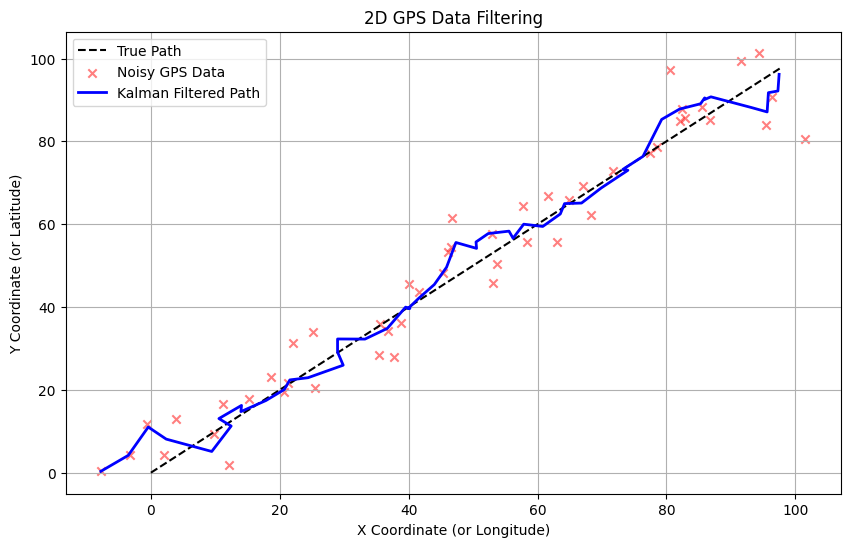

In [7]:
import matplotlib.pyplot as plt

dt = 1.0                
gps_noise_std = 5.0     
process_noise = 0.5     

kf = GPSKalmanFilter(dt=dt, 
                     process_noise_std=process_noise, 
                     measurement_noise_std=gps_noise_std)

num_steps = 50
true_positions = []
noisy_measurements = []

for i in range(num_steps):
    true_x = i * 2.0
    true_y = i * 2.0
    true_positions.append((true_x, true_y))
    
    meas_x = true_x + np.random.normal(0, gps_noise_std)
    meas_y = true_y + np.random.normal(0, gps_noise_std)
    noisy_measurements.append((meas_x, meas_y))

filtered_positions = []

kf.x[0, 0] = noisy_measurements[0][0]
kf.x[1, 0] = noisy_measurements[0][1]

for meas in noisy_measurements:
    kf.predict()  
    filtered_x, filtered_y = kf.update(meas)  
    filtered_positions.append((filtered_x, filtered_y))

plt.figure(figsize=(10, 6))

true_x_vals, true_y_vals = zip(*true_positions)
meas_x_vals, meas_y_vals = zip(*noisy_measurements)
filt_x_vals, filt_y_vals = zip(*filtered_positions)

plt.plot(true_x_vals, true_y_vals, 'k--', label='True Path')
plt.scatter(meas_x_vals, meas_y_vals, c='r', marker='x', alpha=0.5, label='Noisy GPS Data')
plt.plot(filt_x_vals, filt_y_vals, 'b-', linewidth=2, label='Kalman Filtered Path')

plt.title("2D GPS Data Filtering")
plt.xlabel("X Coordinate (or Longitude)")
plt.ylabel("Y Coordinate (or Latitude)")
plt.legend()
plt.grid(True)
plt.show()